In [2]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
include("../src/TensorBinding.jl")
using .TensorBinding
using QuanticsTCI
import TensorCrossInterpolation as TCI

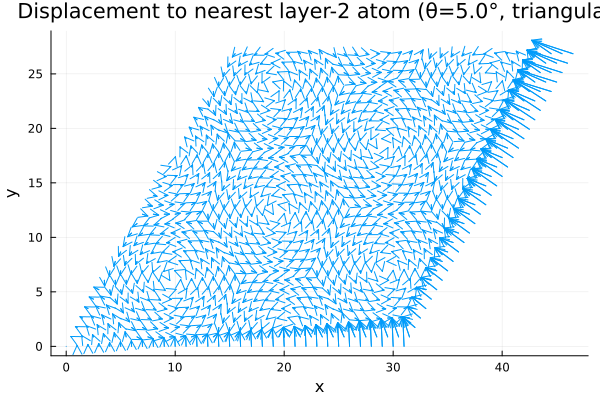

In [3]:
# Displacement quiver: each layer-1 site → its nearest neighbour in layer 2
lattice = :triangular
Lx, Ly  = 5, 5
θ_deg   = 5.0   # twist angle in degrees

pos1 = TensorBinding.lattice_positions(lattice, Lx, Ly; angle_deg=0.0)
pos2 = TensorBinding.lattice_positions(lattice, Lx, Ly; angle_deg=θ_deg)

N = size(pos1, 1)
dx = zeros(N);  dy = zeros(N)
for i in 1:N
    dists = [sum((pos1[i,:] .- pos2[j,:]).^2) for j in 1:N]
    j_nn  = argmin(dists)
    dx[i] = pos2[j_nn, 1] - pos1[i, 1]
    dy[i] = pos2[j_nn, 2] - pos1[i, 2]
end

quiver(pos1[:, 1], pos1[:, 2], quiver=(dx, dy),
    aspect_ratio=:equal,
    title="Displacement to nearest layer-2 atom (θ=$(θ_deg)°, $(lattice))",
    xlabel="x", ylabel="y", label="")

In [ ]:
"""
    bilayer_qe_input(d; ...) -> (scf_str, nscf_str)

QE pw.x inputs for a graphene bilayer with the top layer displaced by
d = (dx, dy) in fractional 2D coordinates. Layer 1 at z=0, layer 2 at z=d_z.
The default structure is AA-stacked graphene (2 C atoms per layer, pz orbitals).
"""
function bilayer_qe_input(d::AbstractVector{<:Real};
        a        = 2.46,    # in-plane lattice constant (Å)
        d_z      = 3.35,    # interlayer spacing (Å)
        c_vac    = 20.0,    # total cell height (Å); should be >> d_z
        element  = "C",
        pseudo   = "C.pbe-n-kjpaw_psl.1.0.0.UPF",
        ecutwfc  = 60.0,
        ecutrho  = 240.0,
        kgrid    = (6, 6, 1),
        prefix   = "bilayer",
        outdir   = "./out",
    )
    dx, dy     = d
    a_bohr     = a * 1.88973        # Å → Bohr
    c_over_a   = c_vac / a
    z2         = d_z / c_vac        # layer-2 fractional z
    kx, ky, kz = kgrid

    system = """
&SYSTEM
  ibrav     = 4
  celldm(1) = $(round(a_bohr;    digits=6))
  celldm(3) = $(round(c_over_a;  digits=6))
  nat       = 4
  ntyp      = 1
  ecutwfc   = $ecutwfc
  ecutrho   = $ecutrho
  occupations = 'smearing'
  smearing    = 'mv'
  degauss     = 0.01
/"""

    atoms = """
ATOMIC_SPECIES
  $element  12.011  $pseudo

ATOMIC_POSITIONS {crystal}
  $element  0.000000                0.000000               0.000000
  $element  0.333333                0.666667               0.000000
  $element  $(round(dx;      digits=6))  $(round(dy;       digits=6))  $(round(z2; digits=6))
  $element  $(round(dx+1/3;  digits=6))  $(round(dy+2/3;  digits=6))  $(round(z2; digits=6))"""

    control(calc) = """
&CONTROL
  calculation = '$calc'
  prefix      = '$prefix'
  outdir      = '$outdir'
  pseudo_dir  = './'
  verbosity   = 'low'
/"""
    kpts = "\nK_POINTS {automatic}\n  $kx $ky $kz  0 0 0\n"

    scf  = control("scf")  * system * "\n&ELECTRONS\n  conv_thr = 1.0e-8\n/\n" * atoms * kpts
    nscf = control("nscf") * system * "\n&ELECTRONS\n  conv_thr = 1.0e-8\n/\n" * atoms * kpts
    return scf, nscf
end


"""
    bilayer_win_input(d; ...) -> String

Wannier90 .win file for the same bilayer geometry.
Projects pz onto all 4 C atoms (2 per layer → 4 Wannier functions total).
"""
function bilayer_win_input(d::AbstractVector{<:Real};
        a            = 2.46,
        d_z          = 3.35,
        c_vac        = 20.0,
        prefix       = "bilayer",
        num_wann     = 4,
        kgrid        = (6, 6, 1),
        dis_win_max  = 5.0,
        dis_froz_max = 2.0,
    )
    dx, dy     = d
    z2         = d_z / c_vac
    kx, ky, kz = kgrid
    kpts_str   = join(["  $(i/kx)  $(j/ky)  0.0" for i in 0:kx-1 for j in 0:ky-1], "\n")

    """
num_wann     = $num_wann
num_bands    = $(num_wann * 2)

dis_win_max  = $dis_win_max
dis_froz_max = $dis_froz_max

begin projections
  f=0.000000,0.000000,0.000000:pz
  f=0.333333,0.666667,0.000000:pz
  f=$(round(dx;     digits=6)),$(round(dy;      digits=6)),$(round(z2;digits=6)):pz
  f=$(round(dx+1/3; digits=6)),$(round(dy+2/3;  digits=6)),$(round(z2;digits=6)):pz
end projections

write_hr = .true.

mp_grid : $kx $ky $kz

begin unit_cell_cart
ang
  $(round(a;      digits=6))  0.000000                    0.000000
  $(round(-a/2;   digits=6))  $(round(a*sqrt(3)/2;digits=6))  0.000000
  0.000000               0.000000                    $(round(c_vac;digits=6))
end unit_cell_cart

begin atoms_frac
  C  0.000000               0.000000              0.000000
  C  0.333333               0.666667              0.000000
  C  $(round(dx;     digits=6))  $(round(dy;      digits=6))  $(round(z2;digits=6))
  C  $(round(dx+1/3; digits=6))  $(round(dy+2/3;  digits=6))  $(round(z2;digits=6))
end atoms_frac

begin kpoints
$kpts_str
end kpoints
"""
end


"""pw2wannier90.x input."""
function pw2wan_input(; prefix="bilayer", outdir="./out")
    """
&INPUTPP
  outdir   = '$outdir'
  prefix   = '$prefix'
  seedname = '$prefix'
  write_mmn = .true.
  write_amn = .true.
  write_unk = .false.
/
"""
end

In [ ]:
"""
    parse_hr_dat(filename) -> NamedTuple

Parse a Wannier90 _hr.dat file.  Returns a NamedTuple with fields:
  .num_wann  — number of Wannier functions
  .nrpts     — number of Wigner-Seitz lattice vectors
  .hr        — Dict mapping (R1,R2,R3,i,j) → H_ij(R) as ComplexF64
"""
function parse_hr_dat(filename::String)
    lines    = readlines(filename)
    num_wann = parse(Int, strip(lines[2]))
    nrpts    = parse(Int, strip(lines[3]))
    ndeg_lines = ceil(Int, nrpts / 15)   # degeneracy weights, 15 per line

    hr = Dict{NTuple{5,Int}, ComplexF64}()
    for line in lines[4+ndeg_lines:end]
        p = split(strip(line))
        length(p) < 7 && continue
        R1, R2, R3 = parse(Int,p[1]), parse(Int,p[2]), parse(Int,p[3])
        i,  j      = parse(Int,p[4]),  parse(Int,p[5])
        val        = parse(Float64,p[6]) + im*parse(Float64,p[7])
        hr[(R1,R2,R3,i,j)] = val
    end
    return (num_wann=num_wann, nrpts=nrpts, hr=hr)
end

"""
    interlayer_block(hr_data; R=(0,0,0), n_per_layer=2) -> Matrix{ComplexF64}

Extract the interlayer hopping block H₁₂(R) from a parsed _hr.dat.
Assumes Wannier indices 1:n belong to layer 1 and n+1:2n to layer 2.
Returns the (n × n) off-diagonal block.
"""
function interlayer_block(hr_data; R=(0,0,0), n_per_layer=2)
    n = n_per_layer
    T = zeros(ComplexF64, n, n)
    for i in 1:n, j in 1:n
        T[i,j] = get(hr_data.hr, (R..., i, n+j), 0.0+0.0im)
    end
    return T
end

In [ ]:
"""
    interlayer_hopping(d; ...) -> Matrix{ComplexF64}

Run QE + Wannier90 for a graphene bilayer displaced by d = (dx, dy)
(fractional 2D coords; d=(0,0) → AA, d=(1/3,2/3) ≈ AB/Bernal).

Returns the (n_per_layer × n_per_layer) interlayer block H₁₂(R=0)
from the Wannier90 real-space Hamiltonian _hr.dat.

This function is the oracle for QTCI: sample it over a grid of d values
to learn t_inter(d) as a tensor train.

Keyword args (beyond geometry kwargs forwarded to the input generators):
  work_dir    — scratch directory (default: mktempdir())
  qe_cmd      — pw.x command  (may include mpirun prefix)
  pw2w90_cmd  — pw2wannier90.x command
  w90_cmd     — wannier90.x command
  n_per_layer — Wannier functions per layer (2 for graphene pz)
"""
function interlayer_hopping(d::AbstractVector{<:Real};
        prefix      = "bilayer",
        work_dir    = mktempdir(),
        qe_cmd      = `pw.x`,
        pw2w90_cmd  = `pw2wannier90.x`,
        w90_cmd     = `wannier90.x`,
        n_per_layer = 2,
        kw...
    )
    outdir = joinpath(work_dir, "out")
    mkpath(outdir)

    scf_in, nscf_in = bilayer_qe_input(d; prefix, outdir, kw...)
    win_in           = bilayer_win_input(d; prefix, kw...)
    p2w_in           = pw2wan_input(; prefix, outdir)

    write(joinpath(work_dir, "$prefix.scf.in"),    scf_in)
    write(joinpath(work_dir, "$prefix.nscf.in"),   nscf_in)
    write(joinpath(work_dir, "$prefix.win"),        win_in)
    write(joinpath(work_dir, "$prefix.pw2wan.in"), p2w_in)

    cd(work_dir) do
        # SCF ground state
        run(pipeline(`$qe_cmd -in $prefix.scf.in`,        stdout="$prefix.scf.out"))
        # NSCF on uniform k-mesh for Wannier90
        run(pipeline(`$qe_cmd -in $prefix.nscf.in`,       stdout="$prefix.nscf.out"))
        # Wannier90 pre-processing (generates .nnkp)
        run(pipeline(`$w90_cmd -pp $prefix`,               stdout="$prefix.wann_pp.out"))
        # pw2wannier90: compute overlaps (mmn) and projections (amn)
        run(pipeline(`$pw2w90_cmd -in $prefix.pw2wan.in`, stdout="$prefix.pw2wan.out"))
        # Wannierization
        run(pipeline(`$w90_cmd $prefix`,                   stdout="$prefix.wout"))
    end

    hr = parse_hr_dat(joinpath(work_dir, "$(prefix)_hr.dat"))
    return interlayer_block(hr; n_per_layer)
end

In [ ]:
# ── QTCI setup ────────────────────────────────────────────────────────────────
#
# The displacement d = (dx, dy) lives in [0,1)² (fractional 2D unit cell).
# Discretise to a 2^L × 2^L grid and label each point with 2L bits → quantics.
# QTCI then adaptively samples interlayer_hopping on this grid.
#
# Example: evaluate on a coarse test grid first to check the pipeline,
# then hand the function to your QTCI routine.

L = 3   # 2^L × 2^L = 8×8 grid; increase for production
N = 2^L

# Scalar target: AA hopping amplitude (modify to extract the element you need)
t_AA(d) = real(interlayer_hopping(collect(d))[1, 1])

# Coarse grid evaluation (embarrassingly parallel in production)
# grid_vals = [t_AA((i/N, j/N)) for i in 0:N-1, j in 0:N-1]

# For QTCI pass t_AA directly as the oracle; the quantics index maps to d via:
#   quantics_to_d(idx, L) = (sum(idx[k]*2^(L-k) for k in 1:L) / N,
#                            sum(idx[L+k]*2^(L-k) for k in 1:L) / N)
#
# Note: each call spawns a full QE+W90 run, so parallelise with Distributed or
# an HPC job array before passing to the QTCI sampler.